## ✅Import Libraries and Tools

In [1]:
import os
import sys

# Move up one directory level to the project root
root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.append(root_path)


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from utils.preprocessing import TextPreprocessor
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

 ## ✅Load the dataset

In [3]:
df=pd.read_csv("../data/raw/WELFake_Dataset.csv", index_col=0)

## ✅Data Verification

In [4]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB


In [6]:
# Checking for the balance of the dataset
df["label"].value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [7]:
df.head(1)

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1


In [8]:
df.shape

(72134, 3)

In [9]:
# Check for nan values before combining the title and text
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [10]:
# Check for duplicates before combining the title and text
df.duplicated().sum()

np.int64(8456)

In [11]:
df.iloc[0]

title    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
text     No comment is expected from Barack Obama Membe...
label                                                    1
Name: 0, dtype: object

## ✅Combining Title and Text Columns
### Data Cleaning

In [12]:
# Combine title and text into a single content column for better analysis
df["content"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()

In [13]:
df = df[['content', 'label']]

In [14]:
df.head()

,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


In [15]:
# Check for nan values in the combined content
df.isnull().sum()

content    0
label      0
dtype: int64

In [16]:
# Check for duplicates in the combined content
df.duplicated().sum()

np.int64(8458)

In [17]:
# Identify conflicting entries where the same content has different labels
conflicts = df.groupby(
    ["content"]
)["label"].nunique()

conflicts = conflicts[conflicts > 1]

if conflicts.empty:
    print("No conflicts found")
else:
    print(conflicts)

No conflicts found


In [18]:
# Remove duplicates based on the combined content, keeping the first occurrence
df=df.drop_duplicates(subset=["content"], keep="first")

## ✅Verification of labels assigned to Fake and Real News

In [19]:
print(df[df["label"]==1].head(1))

                                             content  label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1


In [20]:
print(df[df["label"]==0].head(1))

                                             content  label
3  Bobby Jindal, raised Hindu, uses story of Chri...      0


## ✅Inverting the Labels of the dataset
### - In the original dataset, 0 represents real news and 1 represents fake news. To make it more intuitive, we can invert the labels so that 0 represents fake news and 1 represents real news.

In [21]:
# Invert the labels so that 1 represents real news and 0 represents fake news.
# df['label'] = df['label'].replace({1: 0, 0: 1}) or
df['label'] = 1-df['label']

In [22]:
df["label"].value_counts()

label
1    34790
0    28886
Name: count, dtype: int64

## ✅Distribution of Fake vs Real News

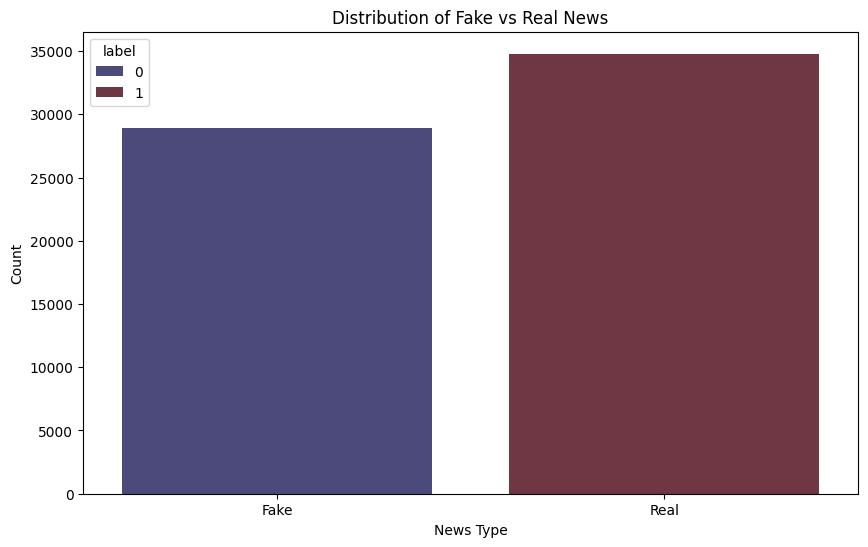

In [23]:
# Visualize the distribution and balance of fake vs real news
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='label',
    hue='label',
    palette='icefire'
    )

plt.title('Distribution of Fake vs Real News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.xticks([0,1], ['Fake', 'Real'])
plt.show()

## ✅Length Distribution of News Articles

In [24]:
#adding two new columns for character length and word length of the content column
df['char_length'] = df['content'].apply(len)
df['word_length'] = df['content'].apply(lambda x: len(x.split()))

In [25]:
df['char_length'].head(1)

0    5180
Name: char_length, dtype: int64

In [26]:
df['word_length'].head(1)

0    889
Name: word_length, dtype: int64

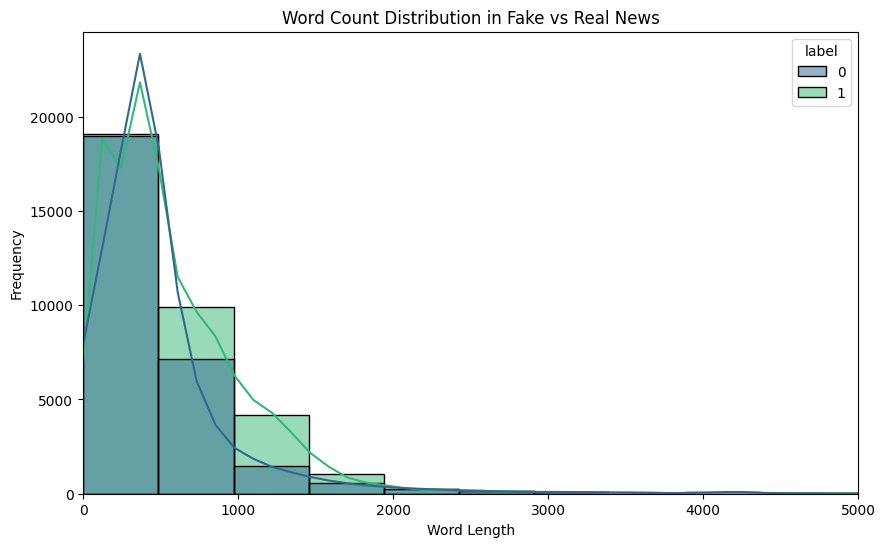

In [27]:
# Distribution of word length in fake vs real news
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_length', hue='label', bins=50, palette='viridis', kde=True)
plt.title('Word Count Distribution in Fake vs Real News')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.xlim(0, 5000)
plt.show()

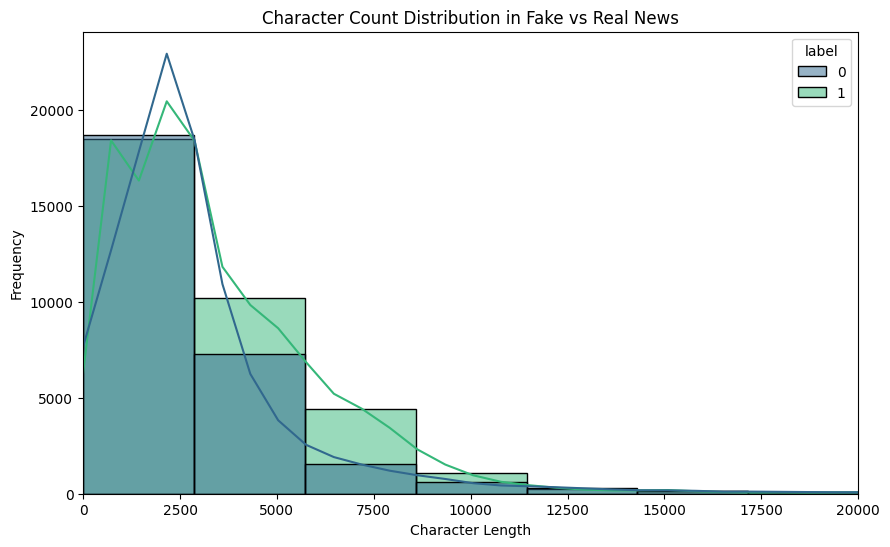

In [28]:
# Distribution of character length in fake vs real news
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='char_length', hue='label', bins=50, palette='viridis', kde=True)
plt.title('Character Count Distribution in Fake vs Real News')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.xlim(0, 20000)
plt.show()

## Observations

- Fake news articles tend to contain longer text bodies.
- Real news distributions appear more concentrated.
- Some fake-news articles exhibit extremely high word counts.
- Text length may serve as a useful feature for classification models.

## ✅Text Preprocessing 

In [29]:
# Preprocess the content column by cleaning the text

processor = TextPreprocessor()

df["clean_content"] = df["content"].apply(processor.clean_text)
df.head()

,content,label,char_length,word_length,clean_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,0,5180,889,law enforcement on high alert following threat...
1,Did they post their votes for Hillary already?,0,46,8,did they post their votes for hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,0,354,52,unbelievable obamas attorney general says most...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",1,8116,1337,bobby jindal raised hindu uses story of christ...
4,SATAN 2: Russia unvelis an image of its terrif...,0,2012,345,satan russia unvelis an image of its terrifyin...


## Saving cleaned dataset

In [30]:
df["clean_content"].isnull().sum()

np.int64(0)

In [ ]:
# save the cleaned dataset for future use in training and evaluation
df.to_csv(
    "../data/processed/cleaned_news.csv",
    index=False
)

## ✅Stopwords Removal

In [32]:
# Remove stopwords from the clean_content column and create a new column for the filtered content
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):

    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)


df["filtered_content"] = df["clean_content"].apply(remove_stopwords)
df.head()

,content,label,char_length,word_length,clean_content,filtered_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,0,5180,889,law enforcement on high alert following threat...,law enforcement high alert following threats c...
1,Did they post their votes for Hillary already?,0,46,8,did they post their votes for hillary already,post votes hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,0,354,52,unbelievable obamas attorney general says most...,unbelievable obamas attorney general says char...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",1,8116,1337,bobby jindal raised hindu uses story of christ...,bobby jindal raised hindu uses story christian...
4,SATAN 2: Russia unvelis an image of its terrif...,0,2012,345,satan russia unvelis an image of its terrifyin...,satan russia unvelis image terrifying new supe...


## ✅WordCloud Visualization

### Real News WordCloud

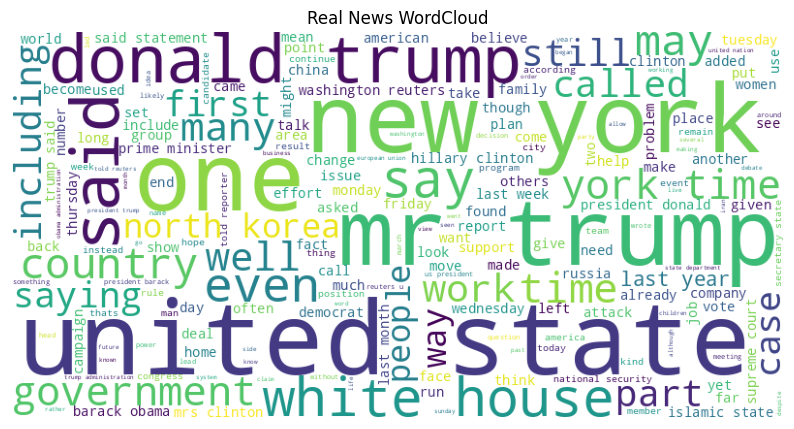

In [33]:
# Generate a word cloud for real news
real_news = " ".join(df[df["label"] == 1]["filtered_content"])


plt.figure(figsize=(10,6))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(real_news)

plt.imshow(wordcloud)
plt.axis('off')
plt.title('Real News WordCloud')
plt.show()

### Fake News WordCloud

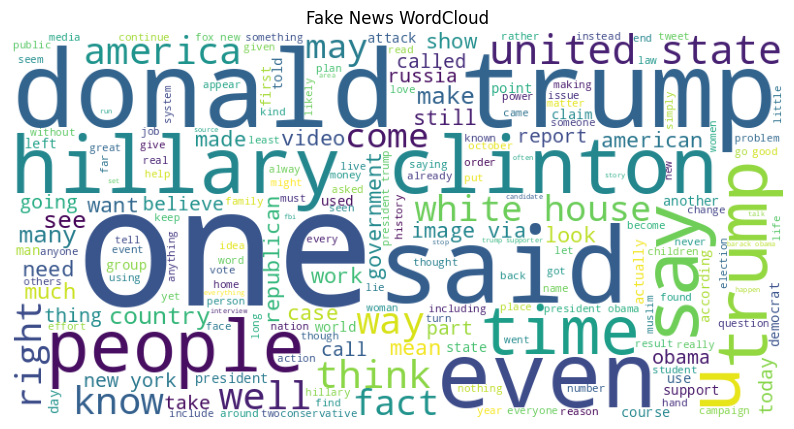

In [34]:
# Generate a word cloud for fake news
fake_news = " ".join(df[df["label"] == 0]["filtered_content"])


plt.figure(figsize=(10,6))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_news)

plt.imshow(wordcloud)
plt.axis('off')
plt.title('Fake News WordCloud')
plt.show()

## ✅Frequent Word Analysis

In [35]:
# Create a list of words for fake news and real news
real_words = real_news.split()

fake_words = fake_news.split()


# Calculate the frequency of words in real news and fake news

real_freq = Counter(real_words)

fake_freq = Counter(fake_words)

# Display the most common words in real news and fake news
print("Most common words in real news:")
print(real_freq.most_common(30))
print("Most common words in fake news:")
print(fake_freq.most_common(30))

Most common words in real news:
[('said', 183337), ('trump', 90220), ('mr', 66088), ('would', 62229), ('us', 56223), ('new', 49857), ('president', 47521), ('one', 41637), ('people', 40957), ('also', 36400), ('state', 35761), ('states', 33873), ('could', 29934), ('house', 29756), ('government', 28596), ('reuters', 28498), ('united', 27555), ('two', 26603), ('last', 26431), ('republican', 26089), ('like', 24609), ('clinton', 24528), ('trumps', 24085), ('told', 23857), ('years', 23530), ('first', 23166), ('campaign', 23151), ('year', 22838), ('time', 22611), ('many', 21370)]
Most common words in fake news:
[('trump', 89207), ('people', 37842), ('us', 37012), ('said', 35594), ('one', 34190), ('would', 33611), ('clinton', 31276), ('president', 28100), ('like', 24952), ('hillary', 23910), ('new', 22279), ('also', 21729), ('donald', 21524), ('obama', 20901), ('even', 20525), ('time', 19264), ('state', 17798), ('news', 16492), ('could', 15786), ('many', 15680), ('get', 15567), ('white', 15515)

In [36]:
# Create dataframes for the most common words in real news and fake news
real_common = pd.DataFrame(
    real_freq.most_common(30),
    columns=["word", "count"]
)

fake_common = pd.DataFrame(
    fake_freq.most_common(30),
    columns=["word", "count"]
)

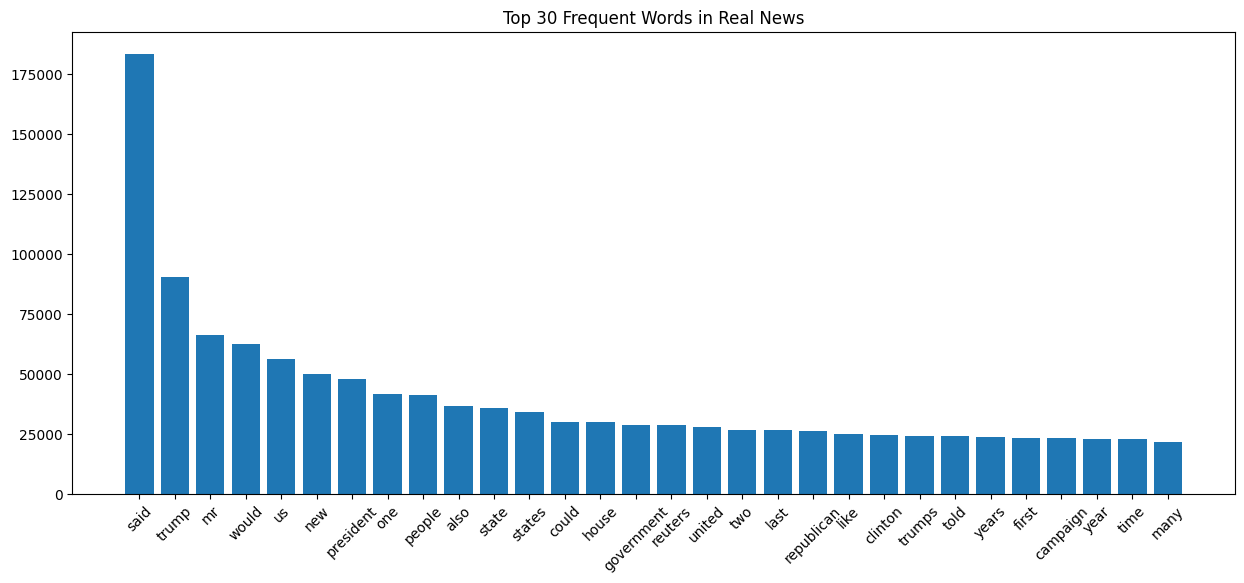

In [37]:
# Visualize the most common words in real news

plt.figure(figsize=(15,6))

plt.bar(real_common["word"], real_common["count"])

plt.xticks(rotation=45)

plt.title("Top 30 Frequent Words in Real News")

plt.show()

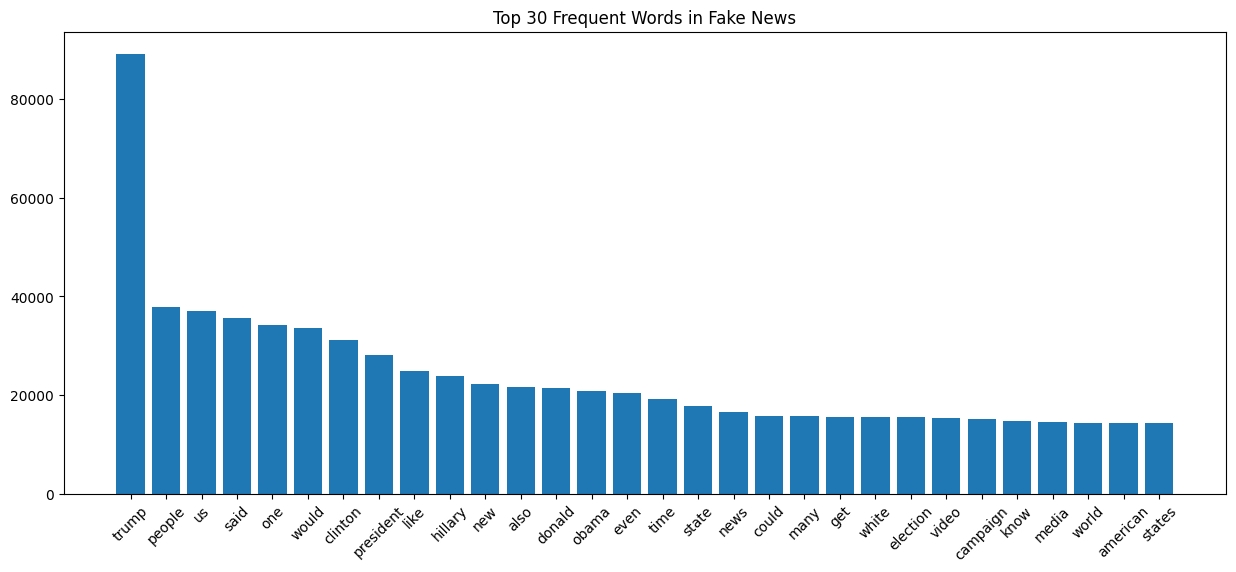

In [38]:
# Visualize the most common words in fake news

plt.figure(figsize=(15,6))

plt.bar(fake_common["word"], fake_common["count"])

plt.xticks(rotation=45)

plt.title("Top 30 Frequent Words in Fake News")

plt.show()

##  ✅ Observations from Frequent Word Analysis

- #### Real news includes more institutional and formal vocabulary.
- #### Fake news articles contain more emotionally charged terms.
- #### Political entities appear frequently in both categories.
- #### Certain sensational terms dominate fake-news content.

## ✅ N-gram Analysis

### Helper Functions:
#### Function 1 — Generate N-gram Frequencies
This function includes:
- corpus preparation
- vectorization
- frequency counting
- dataframe creation
- sorting

In [39]:
# helper function to create n-gram frequency dataframe for a given label (fake or real news)
def create_ngram_freq(
    df,
    label,
    ngram_range=(2,2),
    column="filtered_content",
    max_features=20
):

    # Prepare corpus
    corpus = df[df["label"] == label][column]

    # Vectorization
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        max_features=max_features
    )

    ngrams = vectorizer.fit_transform(corpus)

    # Frequency counts
    counts = ngrams.sum(axis=0)

    # Create dataframe
    ngram_freq = pd.DataFrame({
        "ngram": vectorizer.get_feature_names_out(),
        "count": counts.A1
    })

    # Sort descending
    ngram_freq = ngram_freq.sort_values(
        by="count",
        ascending=False
    )

    return ngram_freq


### Function 2 — Plot N-gram Frequencies

This function includes:

- figure creation
- horizontal bar plotting
- title generation
- y-axis inversion for readability
- visualization rendering

In [40]:
# helper function to plot n-gram frequencies for a given label (fake or real news)

def plot_ngram_freq(
    ngram_df,
    title
):

    plt.figure(figsize=(12,6))

    plt.barh(
        ngram_df["ngram"],
        ngram_df["count"]
    )

    plt.title(title)

    plt.gca().invert_yaxis()

    plt.show()

### ✅ Fake-news bigrams

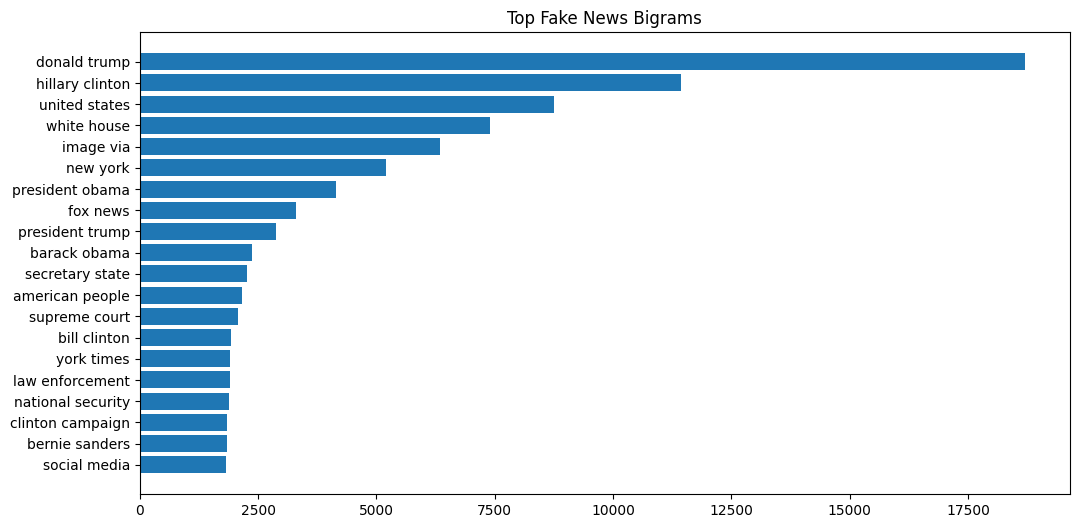

In [41]:
fake_bigrams = create_ngram_freq(
    df,
    label=0,
    ngram_range=(2,2)
)

plot_ngram_freq(
    fake_bigrams,
    "Top Fake News Bigrams"
)

### ✅ Real-news bigrams

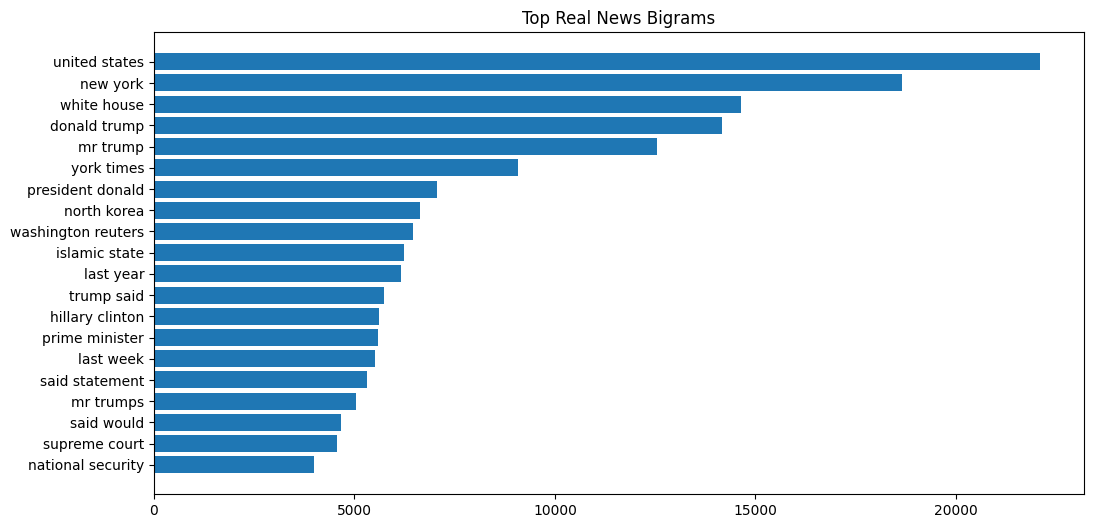

In [42]:
real_bigrams = create_ngram_freq(
    df,
    label=1,
    ngram_range=(2,2)
)

plot_ngram_freq(
    real_bigrams,
    "Top Real News Bigrams"
)

## ✅ Observations from N-gram Analysis

- Fake news contains more emotionally framed bigrams.
- Real news includes more institutional language.
- Political entities dominate both classes.
- Fake-news phrases appear more sensationalized.

In [43]:
df.head()

,content,label,char_length,word_length,clean_content,filtered_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,0,5180,889,law enforcement on high alert following threat...,law enforcement high alert following threats c...
1,Did they post their votes for Hillary already?,0,46,8,did they post their votes for hillary already,post votes hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,0,354,52,unbelievable obamas attorney general says most...,unbelievable obamas attorney general says char...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",1,8116,1337,bobby jindal raised hindu uses story of christ...,bobby jindal raised hindu uses story christian...
4,SATAN 2: Russia unvelis an image of its terrif...,0,2012,345,satan russia unvelis an image of its terrifyin...,satan russia unvelis image terrifying new supe...


## ✅ Final EDA Summary

### Key Findings:
- #### Dataset labels required manual verification and inversion to make it more intuitive.
- #### Duplicate articles were present and removed.
- #### Fake news contains more sensational language.
- #### Real news demonstrates more formal journalistic structure.
- #### Bigram analysis revealed strong political-topic dominance.
- #### Text-length distributions differ between classes.